In [13]:
import numpy as np
import wildfire
from utils.functions import G
import matplotlib.pyplot as plt

kap = 0.1
eps = 0.3
upc = 3
alp = 0
q = 1
x_min, x_max = 0, 1
y_min, y_max = 0, 1
t_min, t_max = 0, 1


h=[]

Nx_vals = np.array([16, 32, 64, 128])
corner_points_kap=[0.08, 0.12]
corner_points_upc=[0.75, 1.75]
results1 = {}  
h = [(x_max - x_min) / (Nx - 1) for Nx in Nx_vals] 
for k in corner_points_kap:
    for u in corner_points_upc:
        fuels=[]
        temps=[]
        for Nx in Nx_vals:

            physical_parameters = {    
                'kap': k, # diffusion coefficient
                'eps': eps, # inverse of activation energy
                'upc': u, # u phase change
                'q': q, # reaction heat
                'alp': alp, 
                'x_lim': (x_min, x_max), # x-axis domain 
                'y_lim': (y_min, y_max), # y-axis domain
                't_lim': (t_min, t_max), # time domain
                'components':(True, False, True) #diffusion, convection, reaction
            }
            wildfire_ = wildfire.Fire(**physical_parameters)
            Ny = Nx
            Nt = 5 * Nx**2
            u0=lambda X, Y: np.exp(-((X-0.5)**2 + (Y-0.5)**2)/0.02) 
            b0 = lambda X, Y: np.ones_like(X)
            V=lambda x, y, t: (0*x, 0*y)
            t, X, Y, U, B = wildfire_.solvePDE(Nx, Ny, Nt, u0, b0, V, 'FD', 'RK4', last=True, acc=2, sparse=False)

            SRQ_betamax_num   = np.max(B)
            fuels.append(SRQ_betamax_num)
            SRQ_umax_num   = np.max(U)
            temps.append(SRQ_umax_num)
        
            
            print("done with Nx =", Nx)
        results1[(k, u)] = {'temps': temps, 'fuels': fuels}
for corner, data in results1.items():
    k, u = corner
    print(f"\nWe are using the corner: kap={k}, upc={u}....................................")
    temps = data['temps']
    fuels = data['fuels']
    print("*****")
    print(fuels)
    print(temps)
    print("*****")
    temp_triplet1cm=temps[0]-temps[1]
    temp_triplet1mf=temps[1]-temps[2]
    temp_triplet2cm=temps[1]-temps[2]
    temp_triplet2mf=temps[2]-temps[3]
    p1=np.log(temp_triplet1cm/temp_triplet1mf)/np.log(2)
    p2=np.log(temp_triplet2cm/temp_triplet2mf)/np.log(2)
    print("====")
    print(p1)
    print(p2)
    print("====")
    fuel_triplet1cm=fuels[0]-fuels[1]
    fuel_triplet1mf=fuels[1]-fuels[2]
    fuel_triplet2cm=fuels[1]-fuels[2]
    fuel_triplet2mf=fuels[2]-fuels[3]
    p3=np.log(fuel_triplet1cm/fuel_triplet1mf)/np.log(2)
    p4=np.log(fuel_triplet2cm/fuel_triplet2mf)/np.log(2)
    print("*****")
    print(p3)
    print(p4)
    print("*****")
    #factor of safety check
    print("*******************Medium to Fine*******************")
    fs=0
    if abs((p2-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0

    print("factor of safety:", fs)
    gci_temp=((fs)/((2**p2)-1))*(abs(temp_triplet2mf))
    print("GCI for temperature:", gci_temp)
    # fuel
    fs=0
    if abs((p4-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0
    print("factor of safety:", fs)
    gci_fuel=((fs)/((2**p4)-1))*(abs(fuel_triplet2mf))
    print("GCI for fuel:", gci_fuel)



    de=(temps[2]-temps[3])/((2**p2)-1)
    print("de for temperature:", de)

    de=(fuels[2]-fuels[3])/((2**p4)-1)
    print("de for fuel:", de)



    print("*******************COARSE TO MEDIUM*******************")
    fs=0
    if abs((p1-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0

    print("factor of safety:", fs)
    gci_temp=((fs)/((2**p1)-1))*(abs(temp_triplet1cm))
    print("GCI for temperature:", gci_temp)
    # fuel
    fs=0
    if abs((p3-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0
    print("factor of safety:", fs)
    gci_fuel=((fs)/((2**p3)-1))*(abs(fuel_triplet1cm))
    print("GCI for fuel:", gci_fuel)

    ubar = temps[2] + ((temps[2] - temps[1])/(2**p1 - 1))
    de = temps[1] - ubar
    print("de for temperature:", de)

    ubar = fuels[2] + ((fuels[2] - fuels[1])/(2**p3 - 1))
    de = fuels[1] - ubar
    print("de for fuel:", de)

all_gci_temp = []
all_gci_fuel = []

for corner, data in results1.items():
    temps = data['temps']
    fuels = data['fuels']
    p2 = np.log((temps[1]-temps[2])/(temps[2]-temps[3])) / np.log(2)
    p4 = np.log((fuels[1]-fuels[2])/(fuels[2]-fuels[3])) / np.log(2)
    fs_t = 1.25 if abs((p2-2)/2) <= 0.1 else 3.0
    fs_f = 1.25 if abs((p4-2)/2) <= 0.1 else 3.0
    all_gci_temp.append((fs_t / (2**p2 - 1)) * abs(temps[2]-temps[3]))
    all_gci_fuel.append((fs_f / (2**p4 - 1)) * abs(fuels[2]-fuels[3]))

print(f"\nMax GCI temp across all corners: {max(all_gci_temp):.6f}")
print(f"Max GCI fuel across all corners: {max(all_gci_fuel):.6f}")



done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128
done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128
done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128
done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128

We are using the corner: kap=0.08, upc=0.75....................................
*****
[np.float64(1.6200641275984873), np.float64(1.625460976659805), np.float64(1.626352354282831), np.float64(1.6265113217439742)]
[np.float64(5.0481059685534015), np.float64(5.091946387574828), np.float64(5.103266391110474), np.float64(5.106136380323066)]
*****
====
1.953387178693546
1.979757189399714
====
*****
2.598008689308084
2.48730525203493
*****
*******************Medium to Fine*******************
factor of safety: 1.25
GCI for temperature: 0.0012184651063132032
factor of safety: 3.0
GCI for fuel: 0.00010351025293246897
de for temperature: -0.0009747720850505626
de for fuel: -3.4503417644156324e-05
***********

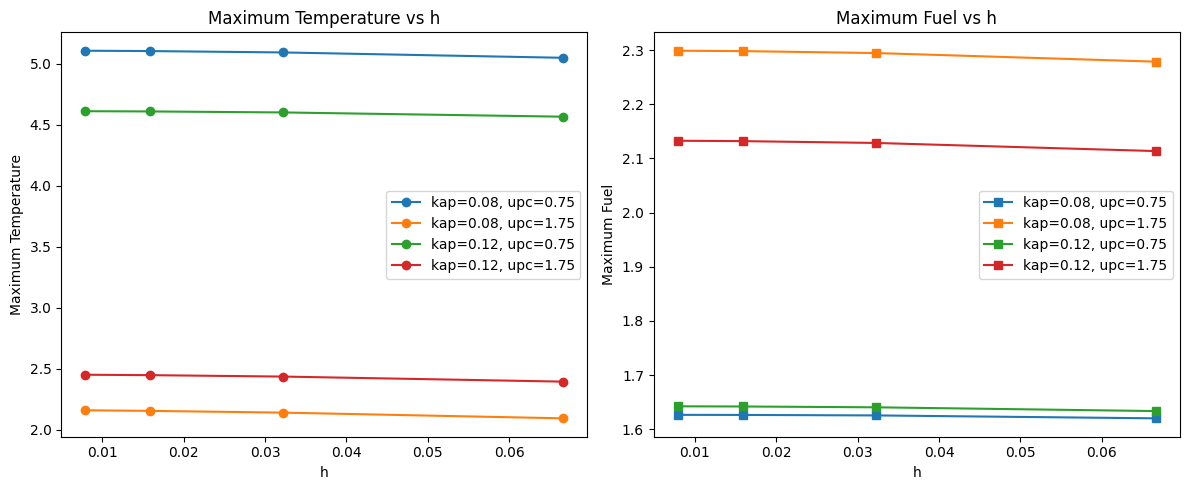

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for corner, data in results.items():
    k, u = corner
    label = f'kap={k}, upc={u}'
    axes[0].plot(h, data['temps'], 'o-', label=label)
    axes[1].plot(h, data['fuels'], 's-', label=label)

axes[0].set_xlabel('h')
axes[0].set_ylabel('Maximum Temperature')
axes[0].set_title('Maximum Temperature vs h')
axes[0].legend()

axes[1].set_xlabel('h')
axes[1].set_ylabel('Maximum Fuel')
axes[1].set_title('Maximum Fuel vs h')
axes[1].legend()

plt.tight_layout()
plt.show()

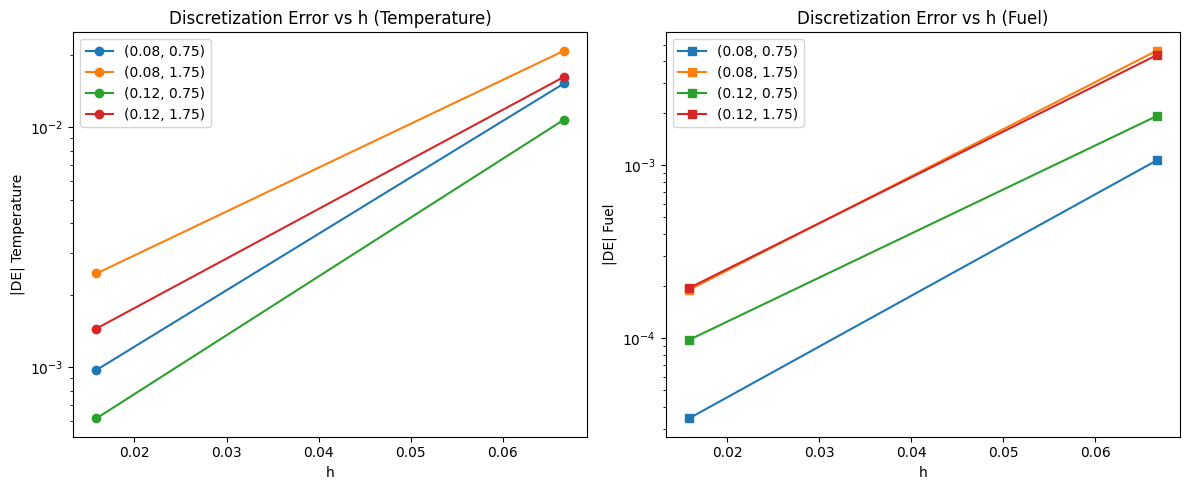

In [4]:
h_coarse = (x_max - x_min) / (16 - 1)  # h for coarse grid
h_medium = (x_max - x_min) / (32 - 1)  # h for medium grid  
h_fine   = (x_max - x_min) / (64 - 1)  # h for fine grid

de_temp_coarse = [-0.015260, -0.020883, -0.010778, -0.016252]
de_temp_fine   = [-0.000975, -0.002462, -0.000613, -0.001451]

de_fuel_coarse = [-0.001068, -0.004604, -0.001928, -0.004336]
de_fuel_fine   = [-3.450e-05, -1.906e-04, -9.802e-05, -1.955e-04]

corners = ['(0.08, 0.75)', '(0.08, 1.75)', '(0.12, 0.75)', '(0.12, 1.75)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, corner in enumerate(corners):
    axes[0].semilogy([h_coarse, h_fine], [abs(de_temp_coarse[i]), abs(de_temp_fine[i])], 'o-', label=corner)
    axes[1].semilogy([h_coarse, h_fine], [abs(de_fuel_coarse[i]), abs(de_fuel_fine[i])], 's-', label=corner)

axes[0].set_xlabel('h')
axes[0].set_ylabel('|DE| Temperature')
axes[0].set_title('Discretization Error vs h (Temperature)')
axes[0].legend()

axes[1].set_xlabel('h')
axes[1].set_ylabel('|DE| Fuel')
axes[1].set_title('Discretization Error vs h (Fuel)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
kap = np.float32(0.1)
eps = np.float32(0.3)
upc = np.float32(3)
alp = np.float32(0)
q = np.float32(1)
x_min, x_max = np.float32(0), np.float32(1)
y_min, y_max = np.float32(0), np.float32(1)
t_min, t_max = np.float32(0), np.float32(1)


h=[]

Nx_vals = np.array([16, 32, 64, 128])
corner_points_kap=[0.08, 0.12]
corner_points_upc=[0.75, 1.75]
results2 = {}  
h = [(x_max - x_min) / (Nx - 1) for Nx in Nx_vals] 
for k in corner_points_kap:
    for u in corner_points_upc:
        fuels=[]
        temps=[]
        for Nx in Nx_vals:

            physical_parameters = {    
                'kap': np.float32(k), # diffusion coefficient
                'eps': eps, # inverse of activation energy
                'upc': np.float32(u), # u phase change
                'q': q, # reaction heat
                'alp': alp, 
                'x_lim': (x_min, x_max), # x-axis domain 
                'y_lim': (y_min, y_max), # y-axis domain
                't_lim': (t_min, t_max), # time domain
                'components':(True, False, True) #diffusion, convection, reaction
            }
            wildfire_ = wildfire.Fire(**physical_parameters)
            Ny = Nx
            Nt = 5 * Nx**2
            u0=lambda X, Y: np.float32(np.exp(-((X-0.5)**2 + (Y-0.5)**2)/0.02)) 
            b0 = lambda X, Y: np.float32(np.ones_like(X))
            V=lambda x, y, t: (0*x, 0*y)
            t, X, Y, U, B = wildfire_.solvePDE(Nx, Ny, Nt, u0, b0, V, 'FD', 'RK4', last=True, acc=2, sparse=False)

            SRQ_betamax_num   = np.max(B)
            fuels.append(np.float32(SRQ_betamax_num))
            SRQ_umax_num   = np.max(U)
            temps.append(np.float32(SRQ_umax_num))
            print("done with Nx =", Nx)
        results2[(k, u)] = {'temps': temps, 'fuels': fuels}

done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128
done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128
done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128
done with Nx = 16
done with Nx = 32
done with Nx = 64
done with Nx = 128


In [15]:

for corner, data in results2.items():
    k, u = corner
    print(f"\nWe are using the corner: kap={k}, upc={u}....................................")
    temps = data['temps']
    fuels = data['fuels']
    print("*****")
    print(fuels)
    print(temps)
    print("*****")
    temp_triplet1cm=temps[0]-temps[1]
    temp_triplet1mf=temps[1]-temps[2]
    temp_triplet2cm=temps[1]-temps[2]
    temp_triplet2mf=temps[2]-temps[3]
    p1=np.log(temp_triplet1cm/temp_triplet1mf)/np.log(2)
    p2=np.log(temp_triplet2cm/temp_triplet2mf)/np.log(2)
    print("====")
    print(p1)
    print(p2)
    print("====")
    fuel_triplet1cm=np.float32(fuels[0]-fuels[1])
    fuel_triplet1mf=np.float32(fuels[1]-fuels[2])
    fuel_triplet2cm=np.float32(fuels[1]-fuels[2])
    fuel_triplet2mf=np.float32(fuels[2]-fuels[3])
    p3=np.float32(np.log(fuel_triplet1cm/fuel_triplet1mf)/np.log(2))
    p4=np.float32(np.log(fuel_triplet2cm/fuel_triplet2mf)/np.log(2))
    print("*****")
    print(p3)
    print(p4)
    print("*****")
    #factor of safety check
    print("*******************Medium to Fine*******************")
    fs=0
    if abs((p2-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0

    print("factor of safety:", fs)
    gci_temp=np.float32(((fs)/((2**p2)-1))*(abs(temp_triplet2mf)))
    print("GCI for temperature:", gci_temp)
    # fuel
    fs=0
    if abs((p4-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0
    print("factor of safety:", fs)
    gci_fuel=np.float32(((fs)/((2**p4)-1))*(abs(fuel_triplet2mf)))
    print("GCI for fuel:", gci_fuel)



    de=(temps[2]-temps[3])/((2**p2)-1)
    print("de for temperature:", de)

    de=(fuels[2]-fuels[3])/((2**p4)-1)
    print("de for fuel:", de)



    print("*******************COARSE TO MEDIUM*******************")
    fs=0
    if abs((p1-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0

    print("factor of safety:", fs)
    gci_temp=((fs)/((2**p1)-1))*(abs(temp_triplet1cm))
    print("GCI for temperature:", gci_temp)
    # fuel
    fs=0
    if abs((p3-2)/2) <= 0.1:
        fs=1.25
    else:
        fs=3.0
    print("factor of safety:", fs)
    gci_fuel=((fs)/((2**p3)-1))*(abs(fuel_triplet1cm))
    print("GCI for fuel:", gci_fuel)

    ubar = temps[2] + ((temps[2] - temps[1])/(2**p1 - 1))
    de = temps[1] - ubar
    print("de for temperature:", de)

    ubar = fuels[2] + ((fuels[2] - fuels[1])/(2**p3 - 1))
    de = fuels[1] - ubar
    print("de for fuel:", de)

all_gci_temp = []
all_gci_fuel = []

for corner, data in results2.items():
    temps = data['temps']
    fuels = data['fuels']
    p2 = np.log((temps[1]-temps[2])/(temps[2]-temps[3])) / np.log(2)
    p4 = np.log((fuels[1]-fuels[2])/(fuels[2]-fuels[3])) / np.log(2)
    fs_t = 1.25 if abs((p2-2)/2) <= 0.1 else 3.0
    fs_f = 1.25 if abs((p4-2)/2) <= 0.1 else 3.0
    all_gci_temp.append((fs_t / (2**p2 - 1)) * abs(temps[2]-temps[3]))
    all_gci_fuel.append((fs_f / (2**p4 - 1)) * abs(fuels[2]-fuels[3]))

print(f"\nMax GCI temp across all corners: {max(all_gci_temp):.6f}")
print(f"Max GCI fuel across all corners: {max(all_gci_fuel):.6f}")




We are using the corner: kap=0.08, upc=0.75....................................
*****
[np.float32(1.620064), np.float32(1.6254611), np.float32(1.6263523), np.float32(1.6265115)]
[np.float32(5.048107), np.float32(5.0919466), np.float32(5.1032667), np.float32(5.1061363)]
*****
====
1.9533412842992415
1.9799638546875027
====
*****
2.5983443
2.485427
*****
*******************Medium to Fine*******************
factor of safety: 1.25
GCI for temperature: 0.0012180686
factor of safety: 3.0
GCI for fuel: 0.00010378982
de for temperature: -0.0009744549212985925
de for fuel: -3.4596607e-05
*******************COARSE TO MEDIUM*******************
factor of safety: 1.25
GCI for temperature: 0.019075865765998994
factor of safety: 3.0
GCI for fuel: 0.0032024377
de for temperature: -0.015260691945003124
de for fuel: -0.0010675192

We are using the corner: kap=0.08, upc=1.75....................................
*****
[np.float32(2.2788084), np.float32(2.294723), np.float32(2.2982936), np.float32(2.299028

In [16]:
for corner in results1:
    k, u = corner
    print(f"\nCorner: kap={k}, upc={u}")
    
    temps64 = np.array(results1[corner]['temps'])
    fuels64 = np.array(results1[corner]['fuels'])
    temps32 = np.array(results2[corner]['temps'])
    fuels32 = np.array(results2[corner]['fuels'])
    
    re_temp = np.abs(temps64 - temps32)
    re_fuel = np.abs(fuels64 - fuels32)
    
    for i, Nx in enumerate([16, 32, 64, 128]):
        print(f"  Nx={Nx}: RE_temp={re_temp[i]:.6e}, RE_fuel={re_fuel[i]:.6e}")


Corner: kap=0.08, upc=0.75
  Nx=16: RE_temp=1.178663e-06, RE_fuel=1.074416e-07
  Nx=32: RE_temp=2.142928e-07, RE_fuel=1.248722e-07
  Nx=64: RE_temp=3.248929e-07, RE_fuel=4.410217e-08
  Nx=128: RE_temp=5.830158e-08, RE_fuel=1.328382e-07

Corner: kap=0.08, upc=1.75
  Nx=16: RE_temp=1.586067e-07, RE_fuel=1.613678e-08
  Nx=32: RE_temp=1.417639e-07, RE_fuel=2.459835e-07
  Nx=64: RE_temp=1.146821e-07, RE_fuel=7.907778e-08
  Nx=128: RE_temp=4.610060e-08, RE_fuel=1.337908e-07

Corner: kap=0.12, upc=0.75
  Nx=16: RE_temp=1.350288e-06, RE_fuel=1.595344e-07
  Nx=32: RE_temp=2.408084e-07, RE_fuel=1.599449e-07
  Nx=64: RE_temp=5.581353e-07, RE_fuel=1.564434e-07
  Nx=128: RE_temp=1.422425e-07, RE_fuel=7.191821e-08

Corner: kap=0.12, upc=1.75
  Nx=16: RE_temp=2.254991e-07, RE_fuel=1.587612e-07
  Nx=32: RE_temp=4.638611e-08, RE_fuel=6.743687e-08
  Nx=64: RE_temp=2.631800e-07, RE_fuel=5.253693e-08
  Nx=128: RE_temp=6.924411e-08, RE_fuel=2.041210e-07


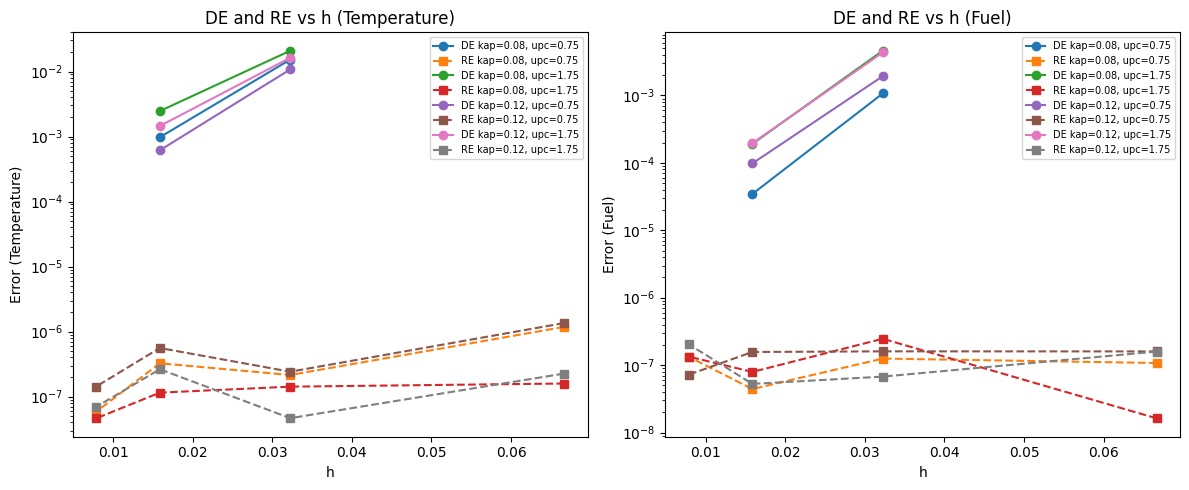

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

de_temp = {
    (0.08, 0.75): [0.015260, 0.000975],
    (0.08, 1.75): [0.020883, 0.002462],
    (0.12, 0.75): [0.010778, 0.000613],
    (0.12, 1.75): [0.016252, 0.001451],
}

de_fuel = {
    (0.08, 0.75): [0.001068, 3.450e-05],
    (0.08, 1.75): [0.004604, 1.906e-04],
    (0.12, 0.75): [0.001928, 9.802e-05],
    (0.12, 1.75): [0.004336, 1.955e-04],
}

h_de = [(x_max - x_min) / (Nx - 1) for Nx in [32, 64]]  # coarse-medium and medium-fine midpoints

for corner in results1:
    k, u = corner
    label = f'kap={k}, upc={u}'

    temps64 = np.array(results1[corner]['temps'])
    fuels64 = np.array(results1[corner]['fuels'])
    temps32 = np.array(results2[corner]['temps'])
    fuels32 = np.array(results2[corner]['fuels'])

    re_temp = np.abs(temps64 - temps32)
    re_fuel = np.abs(fuels64 - fuels32)

    # DE plot
    axes[0].semilogy(h_de, de_temp[corner], 'o-', label=f'DE {label}')
    axes[1].semilogy(h_de, de_fuel[corner], 'o-', label=f'DE {label}')

    # RE plot
    axes[0].semilogy(h, re_temp + 1e-10, 's--', label=f'RE {label}')
    axes[1].semilogy(h, re_fuel + 1e-10, 's--', label=f'RE {label}')

axes[0].set_xlabel('h')
axes[0].set_ylabel('Error (Temperature)')
axes[0].set_title('DE and RE vs h (Temperature)')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('h')
axes[1].set_ylabel('Error (Fuel)')
axes[1].set_title('DE and RE vs h (Fuel)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()